In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

### Import Library
Baris kode di atas digunakan untuk memanggil library yang memiliki fungsi untuk mengolah citra digital. `NumPy` digunakan untuk manipulasi matriks citra, `Matplotlib` berfungsi untuk memvisualisasikan data citra ke dalam bentuk gambar dan histogram, dan `OpenCV` digunakan secara spesifik untuk mempermudah proses konversi warna citra dan membaca file citra, seperti mengubah format menjadi grayscale.

### Membaca File Citra
Baris-baris kode di bawah digunakan untuk membaca file `"Meledak.png"` menggunakan fungsi `cv.imread()`. Setelah itu, citra dikonversi dari format warna BGR ke RGB menggunakan `cv.cvtColor()` agar warna tampil dengan benar saat ditampilkan. Fungsi `plt.imshow()` digunakan untuk menampilkan citra yang telah dibaca.

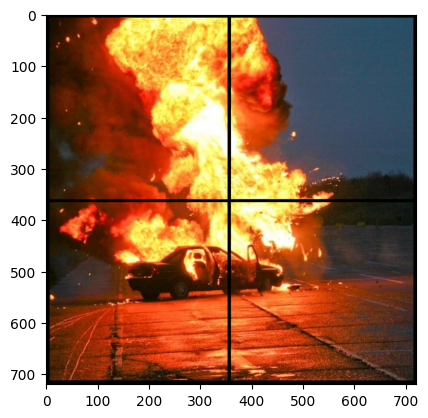

In [3]:
duar1 = cv.imread("Meledak.png")
duar1 = cv.cvtColor(duar1, cv.COLOR_BGR2RGB)
plt.imshow(duar1)

### Fungsi Memotong Citra
Kode di bawah ini digunakan untuk memotong citra berdasarkan rentang indeks tertentu. Jika mode `'H'`, citra dipotong secara horizontal, sedangkan selain itu dipotong secara vertikal. Proses pemotongan dilakukan sebanyak enam tahap, yaitu dua tahap pertama membagi citra menjadi 2 bagian horizontal, kemudian empat tahap berikutnya membagi kedua bagian tersebut menjadi 4 pecahan citra. `plt.subplot()` digunakan agar output dapat ditampilkan pada jendela yang sama, Fungsi `plt.axis('off')` digunakan untuk menghilangkan sumbu-x dan sumbu-y dan fungsi `plt.title()` digunakan untuk memberikan judul pada output

Text(0.5, 1.0, 'part 4')

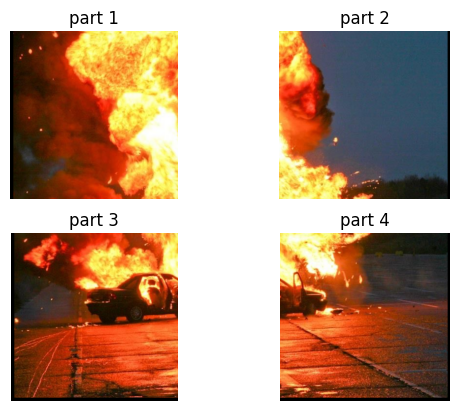

In [4]:
def potong(gambar, a, b, mode='H'):
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

atas1 = potong(duar1, 7, 357)
bawah1 = potong(duar1, 367, 720)
d1 = potong(atas1, 0, 350, 'V')
d2 = potong(atas1, 364, 720, 'V')
d3 = potong(bawah1, 0, 350, 'V')
d4 = potong(bawah1, 364, 720, 'V')

plt.subplot(2,2,1)
plt.imshow(d1)
plt.axis('off')
plt.title('part 1')

plt.subplot(2,2,2)
plt.imshow(d2)
plt.axis('off')
plt.title('part 2')

plt.subplot(2,2,3)
plt.imshow(d3)
plt.axis('off')
plt.title('part 3')

plt.subplot(2,2,4)
plt.imshow(d4)
plt.axis('off')
plt.title('part 4')

### Fungsi Menggabungkan Citra
Kode di bawah ini digunakan untuk menggabungkan dua citra menjadi satu citra baru. Jika parameter `orientation` bernilai `'H'`, kedua citra digabungkan secara horizontal, sedangkan selain itu digabungkan secara vertikal. Proses penggabungan dilakukan dengan membuat matriks kosong berukuran sesuai hasil gabungan, kemudian menyalin piksel dari masing-masing citra ke posisi yang telah ditentukan. Proses penggabungan dilakukan sebanyak tiga tahap, dua tahap pertama adalah menggabungkan 2 citra pada bagian atas dan bawah secara horizontal, setelah itu kedua citra horizontal digabung secara vertikal sehingga membentuk citra utuh.

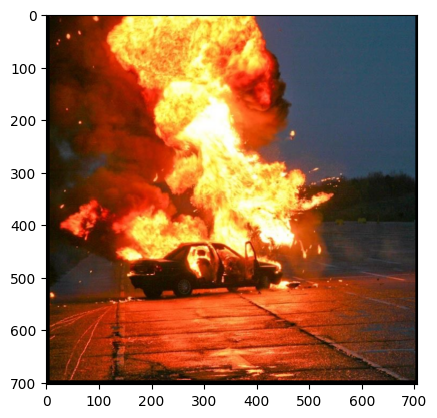

In [5]:
def merge_image(citra1, citra2, orientation='H'):
    if orientation == 'H':
        tinggi = max(citra1.shape[0], citra2.shape[0])
        lebar_total = citra1.shape[1] + citra2.shape[1]

        if len(citra1.shape) == 2:
            gabungan = np.zeros(
                (tinggi, lebar_total),
                dtype=citra1.dtype
            )
        else:
            gabungan = np.zeros(
                (tinggi, lebar_total, citra1.shape[2]),
                dtype=citra1.dtype
            )

        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1

        gabungan[
            0:citra2.shape[0],
            citra1.shape[1]:citra1.shape[1] + citra2.shape[1]
        ] = citra2

    else:
        tinggi_total = citra1.shape[0] + citra2.shape[0]
        lebar = max(citra1.shape[1], citra2.shape[1])

        if len(citra1.shape) == 2:
            gabungan = np.zeros(
                (tinggi_total, lebar),
                dtype=citra1.dtype
            )
        else:
            gabungan = np.zeros(
                (tinggi_total, lebar, citra1.shape[2]),
                dtype=citra1.dtype
            )

        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1

        gabungan[
            citra1.shape[0]:citra1.shape[0] + citra2.shape[0],
            0:citra2.shape[1]
        ] = citra2

    return gabungan

atas2 = merge_image(d1,d2,'H')
bawah2 = merge_image(d3,d4, 'H')
duar_merge = merge_image(atas2,bawah2,'V')
plt.imshow(duar_merge)

### Fungsi Dilatasi Citra
Kode di bawah ini digunakan untuk melakukan dilatasi atau scaling area citra berdasarkan batas atas, bawah, kiri, dan kanan yang ditentukan oleh parameter `p1`, `p2`, `p3`, dan `p4`. Proses dilakukan dengan menyalin seluruh piksel citra ke matriks baru, kemudian mengambil bagian citra sesuai rentang indeks yang telah dihitung. Hasil citra dari proses penggabungan sebelumnya dipanggil dan dipotong bagian bawah, kiri dan kanannya sehingga citra bersih dari area hitam.

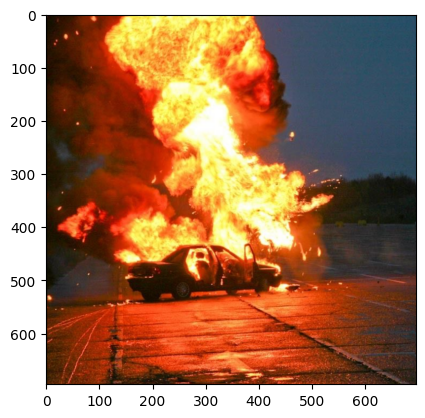

In [6]:
def dilatasi(image, p1=0, p2=0, p3=0, p4=0):
    h, w, c = image.shape
    dilated = np.zeros((h, w, c), dtype=image.dtype)
    for y in range(h):
        for x in range(w):
            dilated[y][x] = image[int(y)][int(x)]
    sy, ey = max(0, p1), min(h, h - p2)
    sx, ex = max(0, p3), min(w, w - p4)
    return dilated[sy:ey, sx:ex]

duar2=dilatasi(duar_merge, 0,7,5,5)
plt.imshow(duar2)

### Mengubah Citra Menjadi Grayscale
Kode di bawah ini digunakan untuk mengubah citra berwarna `"Meledak.png"` yang telah melalui banyak proses menjadi citra grayscale menggunakan fungsi `cv.cvtColor()` dengan parameter `cv.COLOR_RGB2GRAY`. Setelah itu, citra grayscale ditampilkan menggunakan `plt.imshow()` dengan colormap `"gray"` sehingga warna pada citra menjadi abu.

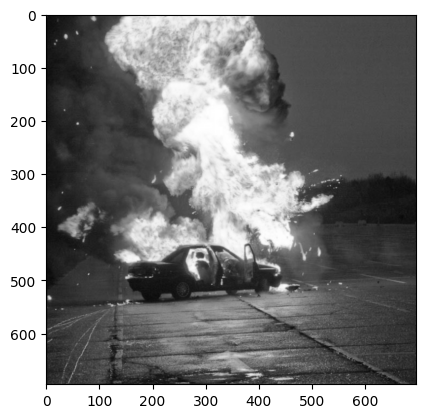

In [7]:
duar2gray = cv.cvtColor(duar2, cv.COLOR_RGB2GRAY)
plt.imshow(duar2gray, cmap="gray")

### Fungsi Ekualisasi Citra
Kode di bawah ini digunakan untuk melakukan ekualisasi histogram pada citra grayscale guna meningkatkan kontras citra. Proses diawali dengan menghitung histogram intensitas piksel, kemudian membentuk Cumulative Distribution Function (CDF) untuk memperoleh distribusi kumulatif piksel. Nilai CDF tersebut dinormalisasi ke rentang 0–255 sehingga menghasilkan nilai intensitas baru untuk setiap piksel. Selanjutnya, setiap piksel pada citra asli diganti dengan nilai hasil pemetaan sehingga diperoleh citra dengan kontras yang lebih merata.

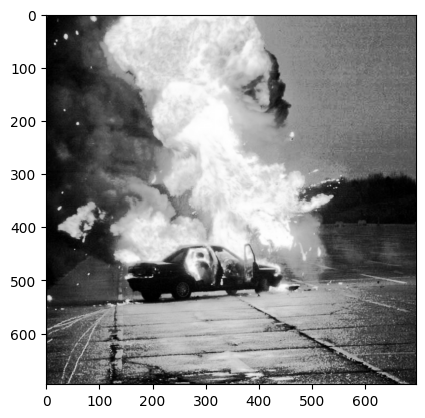

In [8]:
def ekualisasi(image):
    hist = np.zeros(256, dtype=int)
    height, width = image.shape
    for i in range(height):
        for j in range(width):
            val = image[i, j]
            hist[val] += 1

    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(hist[0:i+1])

    hasil = np.round(((cdf * 255) / (height * width))).astype(np.uint8)

    equalized_img = np.zeros_like(image)
    for i in range(height):
        for j in range(width):
            equalized_img[i, j] = hasil[image[i, j]]

    return equalized_img

duar2e = ekualisasi(duar2gray)
plt.imshow(duar2e, cmap ="gray")

### Histogram Sebelum dan Sesudah Ekualisasi
Kode di bawah ini digunakan untuk membuat dan menampilkan histogram dari citra grayscale sebelum dan sesudah proses ekualisasi. Fungsi `buat_hist()` menghitung jumlah kemunculan setiap intensitas piksel dari 0-255 dengan melakukan iterasi pada seluruh piksel citra. Selanjutnya, fungsi `plot_histogram()` digunakan untuk menampilkan histogram menggunakan diagram batang dengan warna tertentu. Fungsi `plt.figure()` digunakan untuk menentukan ukuran tampilan grafik, sedangkan `plt.legend()` digunakan untuk menampilkan keterangan masing-masing histogram. `plt.tight_layout()` berfungsi merapikan tata letak elemen grafik agar tidak saling bertumpuk, dan `plt.show()` digunakan untuk menampilkan hasil visualisasi histogram. Kedua histogram ditampilkan dalam satu figure sehingga distribusi intensitas piksel sebelum dan sesudah ekualisasi dapat dibandingkan secara langsung.

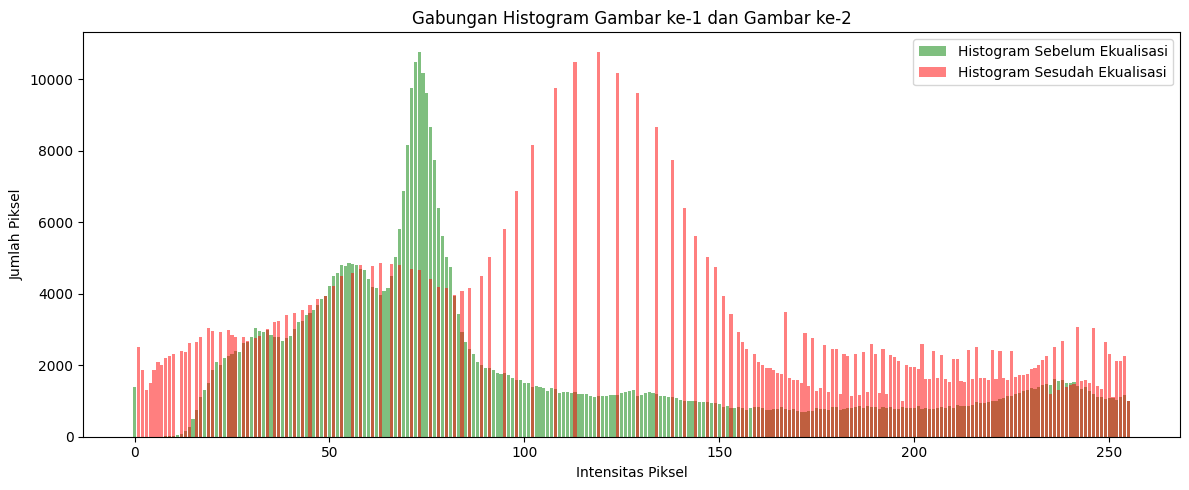

In [9]:
def buat_hist(citra):
    histogram = [0] * 256
    height = len(citra)
    width = len(citra[0]) if height > 0 else 0
    for i in range(height):
        for j in range(width):
            val = int(citra[i][j]) 
            histogram[val] += 1 
    return histogram

def plot_histogram(histogram, title, ImgColor):
    plt.xlabel("Intensitas Piksel")
    plt.title(title)
    plt.ylabel("Jumlah Piksel")
    plt.bar(range(256),histogram,color=ImgColor,width=0.8,alpha=0.5)

duar2hist = buat_hist(duar2gray)
duar2ehist = buat_hist(duar2e)
plt.figure(figsize=(12,5))
plot_histogram(duar2hist,"Gabungan Histogram Gambar ke-1 dan Gambar ke-2","green")
plot_histogram(duar2ehist,"Gabungan Histogram Gambar ke-1 dan Gambar ke-2","red")
plt.legend(["Histogram Sebelum Ekualisasi","Histogram Sesudah Ekualisasi"])
plt.tight_layout()
plt.show()

### Membaca Dua File Citra Baru 
Kode di bawah ini digunakan untuk membaca file citra `"Windut.png"` dan `"Bunga.png"` menggunakan `cv.imread()`. Setelah itu, citra dikonversi dari format BGR ke RGB agar warna tampil dengan benar, lalu diubah menjadi citra grayscale menggunakan `cv.cvtColor()`. Kedua citra ditampilkan dalam satu jendela dan menggunakan `cmap = "gray"` agar warnanya menjadi abu.

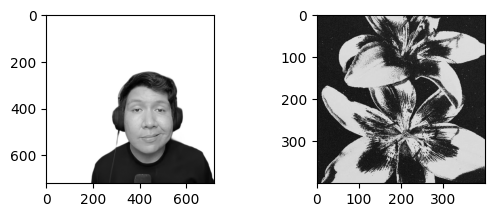

In [10]:
wdh = cv.imread("Windut.png")
wdh = cv.cvtColor(wdh, cv.COLOR_BGR2RGB)
wdhgray = cv.cvtColor(wdh, cv.COLOR_RGB2GRAY)
bng = cv.imread("Bunga.png")
bng = cv.cvtColor(bng, cv.COLOR_BGR2RGB)
bng_gray = cv.cvtColor(bng, cv.COLOR_RGB2GRAY)
plt.subplot(2,2,1)
plt.imshow(wdhgray, cmap = "gray")
plt.subplot(2,2,2)
plt.imshow(bng_gray, cmap = "gray")

### Fungsi Spesifikasi Citra
Kode di bawah ini digunakan untuk melakukan spesifikasi histogram antara citra asal yaitu `wdhgray` dan citra target yaitu `bng_gray`. Proses dimulai dengan menghitung histogram masing-masing citra, kemudian CDF untuk mengetahui distribusi kumulatif intensitas piksel pada kedua citra. Setelah itu, dilakukan pencarian nilai intensitas pada citra target yang memiliki distribusi paling mendekati intensitas pada citra asal sehingga terbentuk tabel pemetaan histogram `(map_hist)`. Selanjutnya, setiap piksel pada citra asal diganti berdasarkan hasil pemetaan tersebut sehingga distribusi histogram citra hasil menjadi menyerupai citra target. 

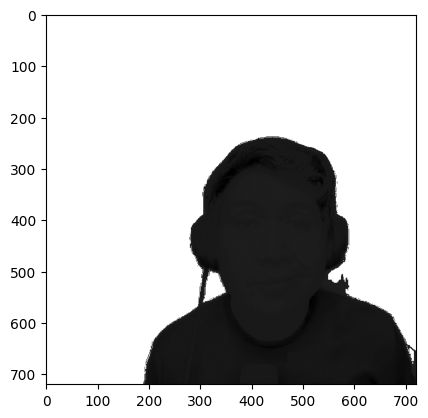

In [11]:
def spesifikasi_histogram(citra_asal, citra_target):
    hist_asal = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)
   
    height_a, width_a = citra_asal.shape
    for y in range(height_a):
        for x in range(width_a):
            hist_asal[citra_asal[y, x]] += 1          
    
    height_t, width_t = citra_target.shape
    for y in range(height_t):
        for x in range(width_t):
            hist_target[citra_target[y, x]] += 1

    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)
    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]
    
    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i-1] + hist_asal[i]
        cdf_target[i] = cdf_target[i-1] + hist_target[i]
    cdf_asal = cdf_asal / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]
    map_hist = np.zeros(256, dtype=np.uint8)
    
    for i in range(256):
        selisih_terkecil = float('inf')
        nilai_j_terbaik = 0
        for j in range(256):
            selisih = abs(cdf_target[j] - cdf_asal[i])
            if selisih < selisih_terkecil:
                selisih_terkecil = selisih
                nilai_j_terbaik = j
        map_hist[i] = nilai_j_terbaik

    height, width = citra_asal.shape
    hasil = np.zeros((height, width), dtype=np.uint8) 
    
    for y in range(height):
        for x in range(width):
            hasil[y, x] = map_hist[citra_asal[y, x]]
            
    return hasil

def plot_histogram_1(histogram, title, ImgColor):
    plt.figure(figsize=(10, 5))
    plt.xlabel("Intensitas Piksel")
    plt.title(title)
    plt.ylabel("Jumlah Piksel")
    plt.bar(range(256), histogram, color=ImgColor, width=0.8)
    plt.show()

windah2 = spesifikasi_histogram(wdhgray,bng_gray)
plt.imshow(windah2, cmap = "gray")

### Histogram Citra Sesudah Spesifikasi
Kode di bawah ini digunakan untuk membuat histogram dari citra hasil spesifikasi histogram yaitu `windah2` dengan memanggil fungsi `buat_hist()` untuk membentuk histogram terlebih dahulu, kemudian menampilkannya menggunakan fungsi `plot_histogram_1()` dengan salah satu parameter bernilai `"red"` agar diagram batangnya berwarna merah.

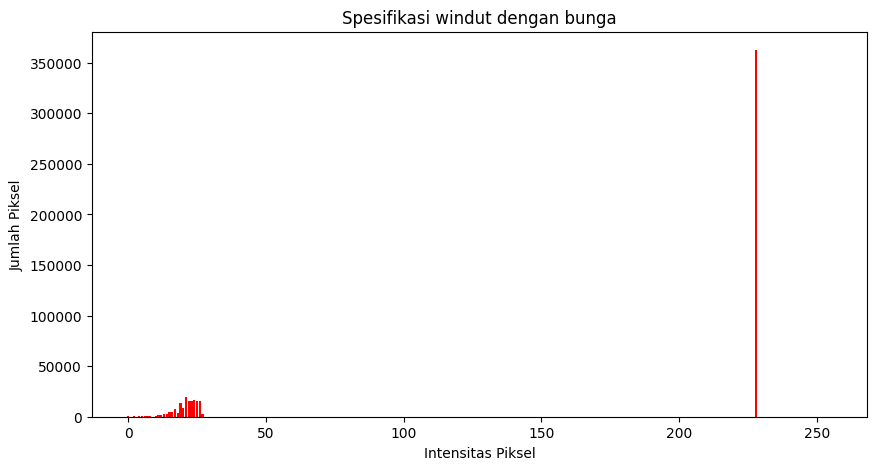

In [12]:
whisto = buat_hist(windah2)
windah2hist = plot_histogram_1(whisto, "Spesifikasi windut dengan bunga", "red")

### Fungi Crop Citra 
Kode di bawah ini digunakan untuk memotong citra `windah2` menggunakan fungsi `cropping()` dengan mengurangi 24 piksel pada bagian bawah dan kanan citra. Tujuannya adalah menyamakan ukuran citra `windah_crop` dengan `duar2e`. Fungsi `print(windah2.shape)` dan `print(duar2e.shape)` digunakan untuk menampilkan ukuran masing-masing citra untuk memudahkan proses crop.

(720, 720)
(696, 696)


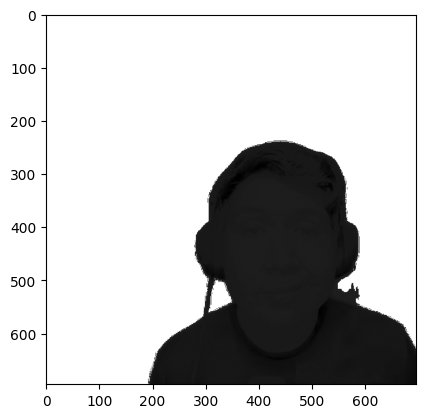

In [13]:
def cropping(citra, potong_atas, potong_bawah, potong_kiri, potong_kanan):
    tinggi_citra, lebar_citra = citra.shape[:2]
    hasil_crop = citra[potong_atas:tinggi_citra - potong_bawah,potong_kiri:lebar_citra - potong_kanan]
    return hasil_crop

windah_crop = cropping(windah2, 0, 24, 0, 24)
print(windah2.shape)
print(duar2e.shape)
plt.imshow(windah_crop, cmap="gray")

### Fungsi Masking Citra
Kode di bawah ini digunakan untuk melakukan masking pada citra `duar2e` berdasarkan nilai intensitas piksel pada `windah_crop`. Matriks hasil dibuat dengan ukuran yang sama seperti `duar2e`, kemudian setiap piksel pada `duar2e` akan disalin ke hasil jika nilai piksel pada `windah_crop` lebih besar dari 50. Setelah itu, citra hasil masking ditampilkan menggunakan `plt.imshow()`.

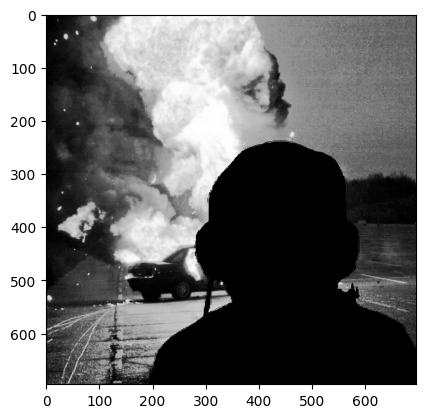

In [14]:
hasil = np.zeros_like(duar2e, dtype=int)
for i in range(hasil.shape[0]):
    for j in range(hasil.shape[1]):
        if(windah_crop[i,j]>50):
            hasil[i,j] = duar2e[i,j]
plt.imshow(hasil, cmap="gray")

Kode di bawah ini digunakan untuk menggabungkan citra `hasil` dengan `wdhgray`. Jika nilai piksel pada `hasil` kurang dari 1, maka piksel dari `wdhgray` digunakan, sedangkan selain itu digunakan piksel dari `hasil`. Proses ini menghasilkan citra gabungan yaitu `hasil_merge` yang kemudian ditampilkan menggunakan `plt.imshow()`.

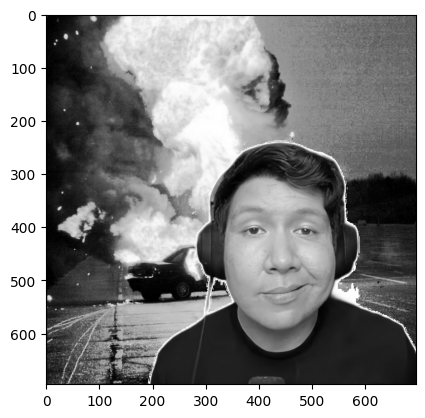

In [15]:
hasil_merge = np.zeros_like(hasil, dtype=int)
for i in range(hasil_merge.shape[0]):
    for j in range(hasil_merge.shape[1]):
        if(hasil[i,j]<1):
            hasil_merge[i,j] = wdhgray[i,j]
        else:
             hasil_merge[i,j] = hasil[i,j]
plt.imshow(hasil_merge, cmap="gray")

### Membaca File Citra Baru dan Spesifikasi Pada Citra Hasil Masking

Kode di bawah ini digunakan untuk membaca file citra `"Langit.png"` menggunakan `cv.imread()`, kemudian mengubahnya menjadi citra grayscale dengan `cv.cvtColor()`. Setelah itu, dilakukan spesifikasi histogram menggunakan fungsi `spesifikasi_histogram()` pada citra `hasil_merge` menggunakan histogram dari citra `langit` sebagai referensi sehingga distribusi intensitas piksel citra hasil menjadi menyerupai citra target.

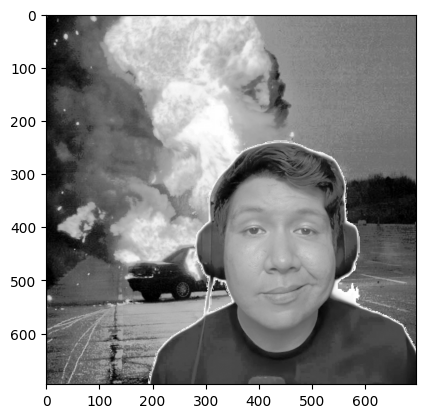

In [16]:
langit = cv.imread("Langit.png")
langit = cv.cvtColor(langit, cv.COLOR_BGR2GRAY)
wdh_sp = spesifikasi_histogram(hasil_merge, langit)
plt.imshow(wdh_sp, cmap = "gray")

### Histogram Spesifikasi Windut dengan Langit
Kode di bawah ini digunakan untuk membuat histogram dari citra hasil spesifikasi histogram yaitu `wdhsp_hist` dengan memanggil fungsi `buat_hist()` untuk membentuk histogram terlebih dahulu, kemudian menampilkannya menggunakan fungsi `plot_histogram_1()` dengan salah satu parameter bernilai `"red"` agar diagram batangnya berwarna merah.

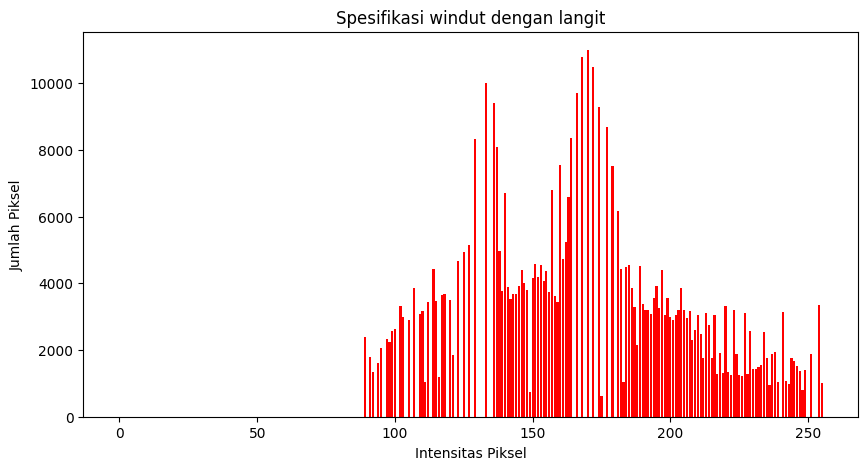

In [17]:
wdhsp_hist=buat_hist(wdh_sp)
Windah_SP = plot_histogram_1(wdhsp_hist, "Spesifikasi windut dengan langit", "red")

### Membaca Kembali File Citra
Kode di bawah ini digunakan untuk membaca kembali citra `"Windut.png"` dan mengonversi citra `duar2` dari format RGB ke BGR menggunakan `cv.cvtColor()`. Fungsi `plt.subplot()` digunakan untuk menampilkan kedua citra dalam satu jendela dengan posisi yang berbeda.

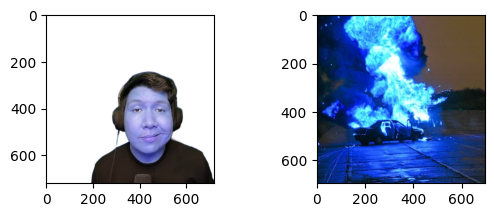

In [18]:
windahfix = cv.imread("Windut.png")
duarfix = cv.cvtColor(duar2, cv.COLOR_RGB2BGR)

plt.subplot(2,2,1)
plt.imshow(windahfix)
plt.subplot(2,2,2)
plt.imshow(duarfix)

### Menggabungkan Dua Citra Berwarna
Kode di bawah ini digunakan untuk menggabungkan citra `duarfix` dengan `windahfix` berdasarkan nilai intensitas piksel pada `wdhgray`. Jika nilai piksel pada `wdhgray` lebih besar dari 240, maka piksel dari `duarfix` digunakan, sedangkan selain itu digunakan piksel dari `windahfix`. Hasil penggabungan yaitu `hasil_fix` kemudian ditampilkan menggunakan `plt.imshow()`.

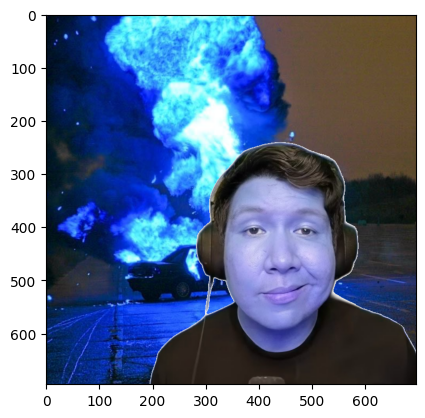

In [19]:
hasil_fix = np.zeros_like(duarfix, dtype=int)
for i in range(hasil_fix.shape[0]):
    for j in range(hasil_fix.shape[1]):
        if(wdhgray[i,j]>240):
            hasil_fix[i,j] = duarfix[i,j]
        else:
            hasil_fix[i,j] = windahfix[i,j]
plt.imshow(hasil_fix)